In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.datasets import load_iris
iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['species'] = iris.target
df.head()


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [3]:
df['species'] = df['species'].apply(lambda x: iris.target_names[x])
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [4]:
from sklearn.model_selection import train_test_split
df_train , df_test = train_test_split(df, test_size=0.2, random_state=42)



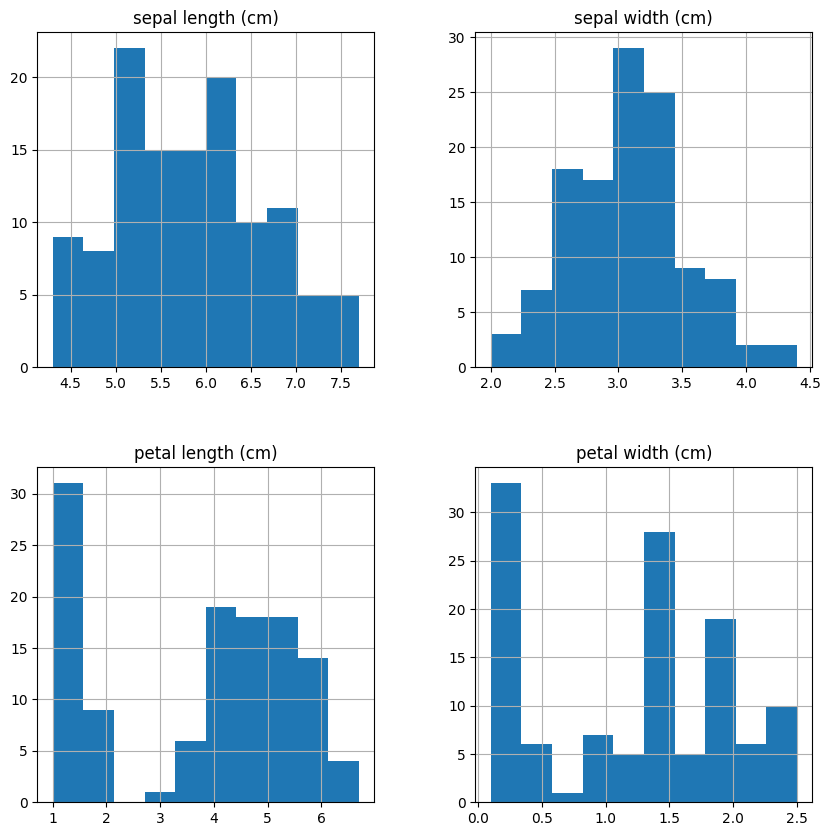

In [5]:
len(df_train)
df_train.hist(figsize=(10,10))
plt.show()

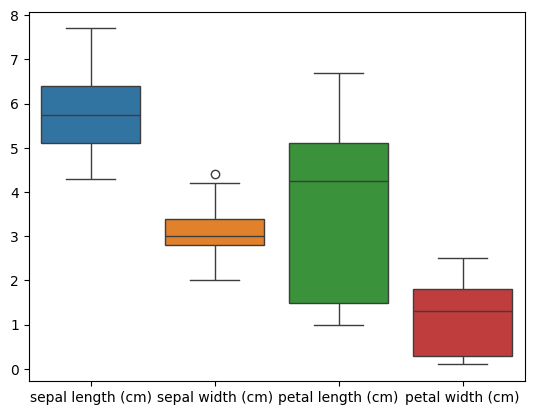

In [6]:
sns.boxplot(data=df_train)
plt.show()

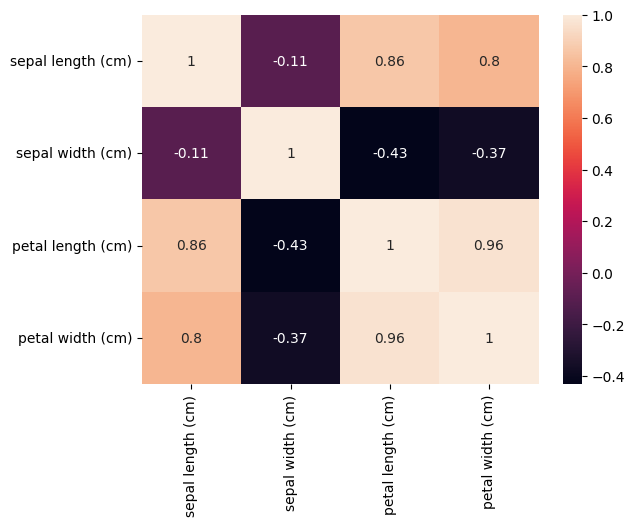

In [7]:

# Correlation heatmap
sns.heatmap(df_train.drop('species', axis=1).corr(), annot=True)
plt.show()

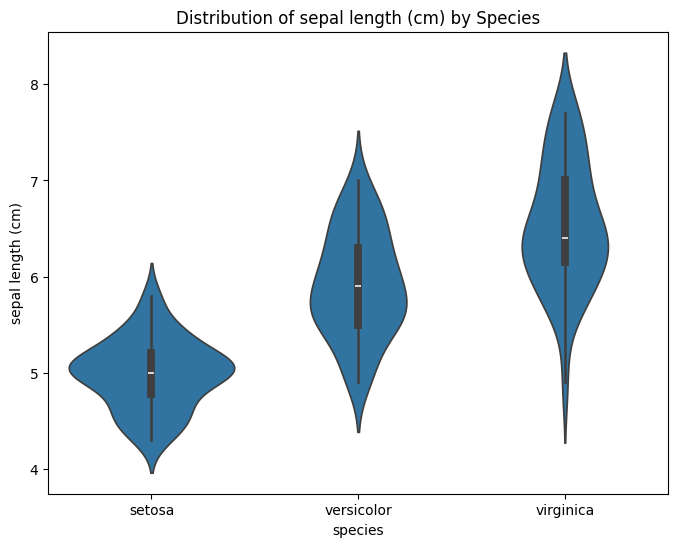

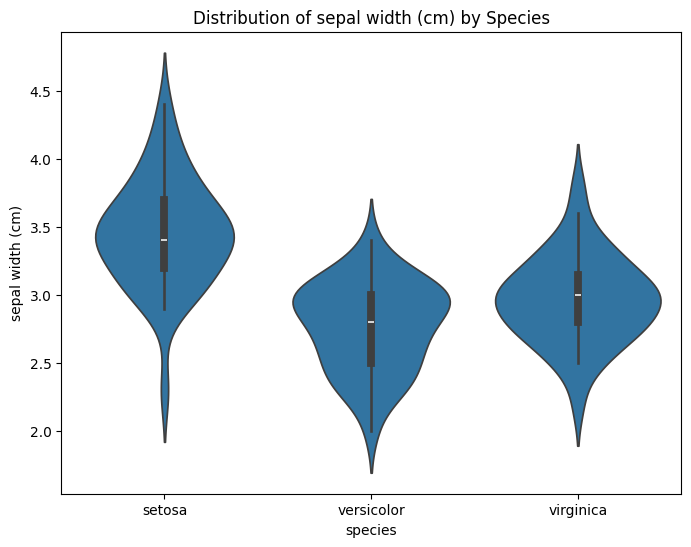

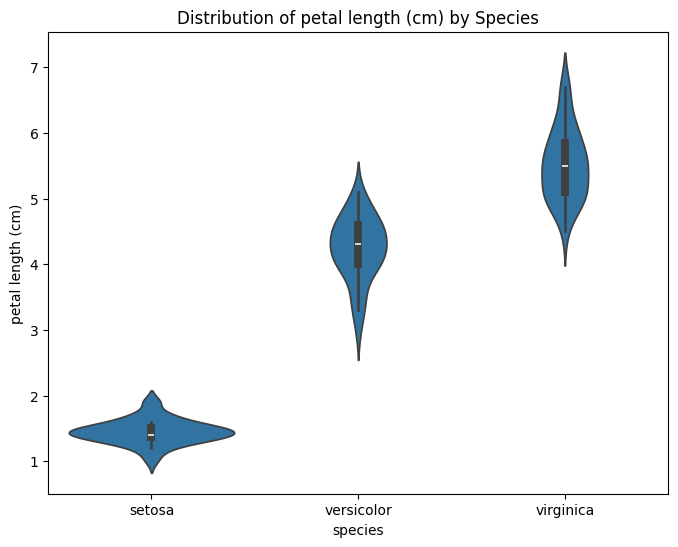

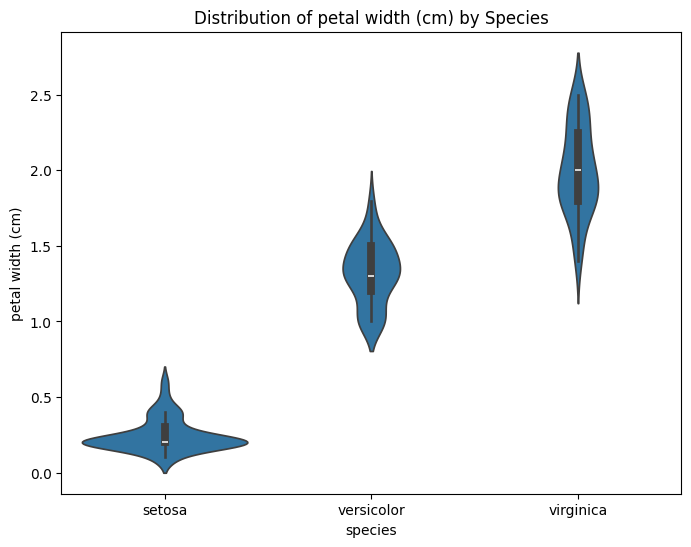

In [8]:
for column in df_train.drop('species', axis=1).columns:
    plt.figure(figsize=(8, 6))
    sns.violinplot(x='species', y=column, data=df_train)
    plt.title(f'Distribution of {column} by Species')
    plt.show()

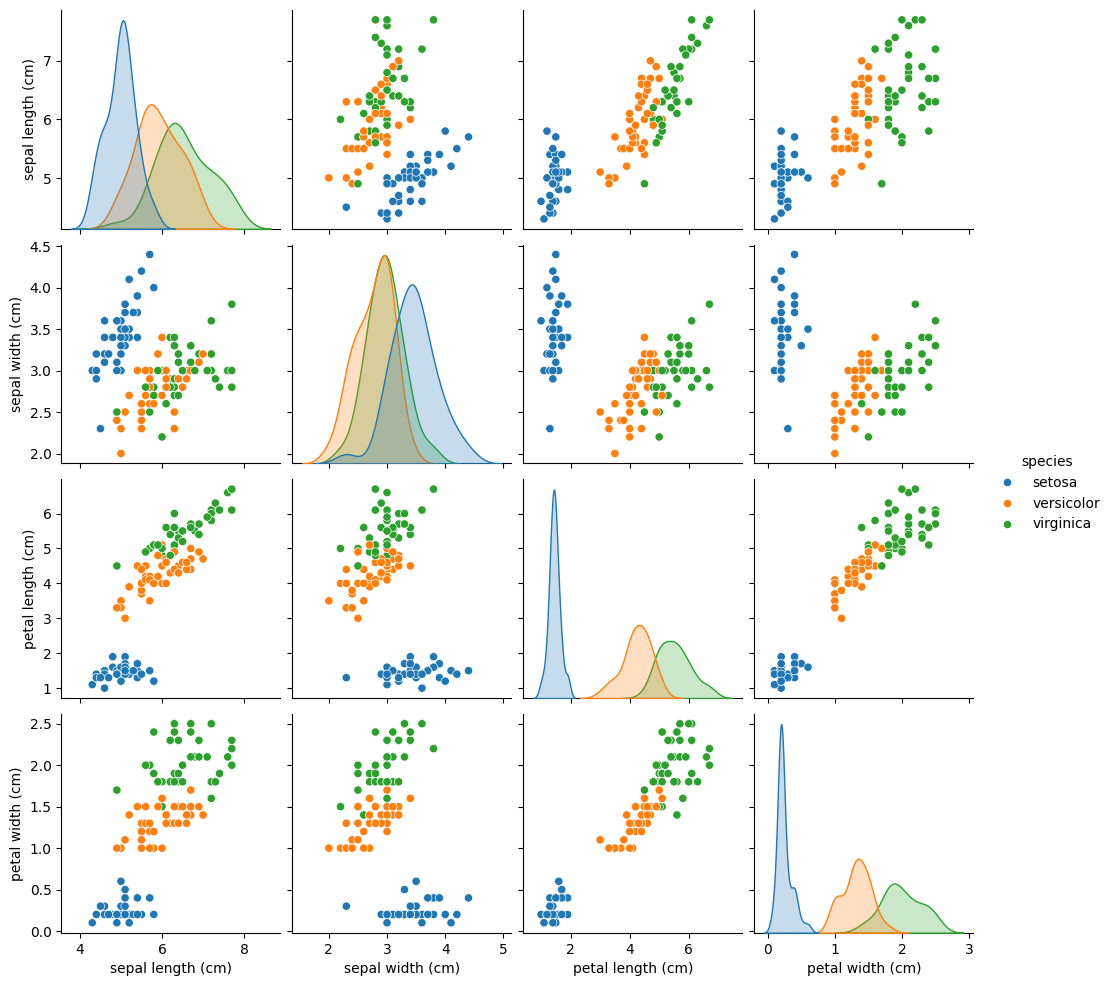

In [9]:
sns.pairplot(df_train, hue='species', diag_kind='kde')
plt.show()

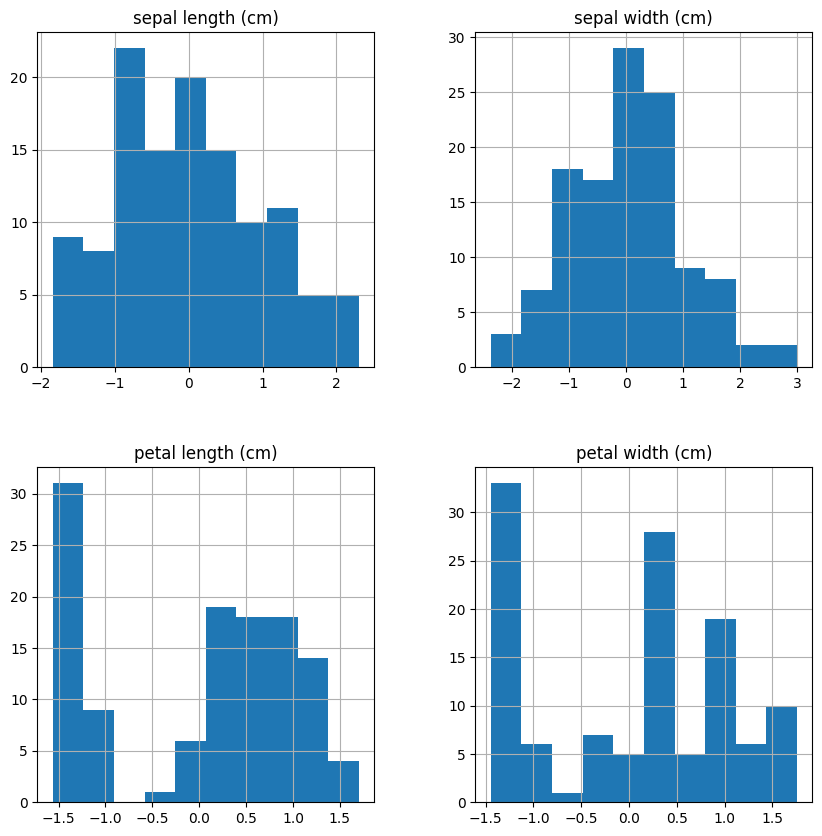

In [10]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(df_train.drop('species', axis=1))

scaled_data = scaler.transform(df_train.drop('species', axis=1))

scaled_df_train = pd.DataFrame(
    scaled_data,
    columns=df.columns[:-1]   # all columns except 'species'
)

scaled_df_train.hist(figsize=(10,10))
plt.show()

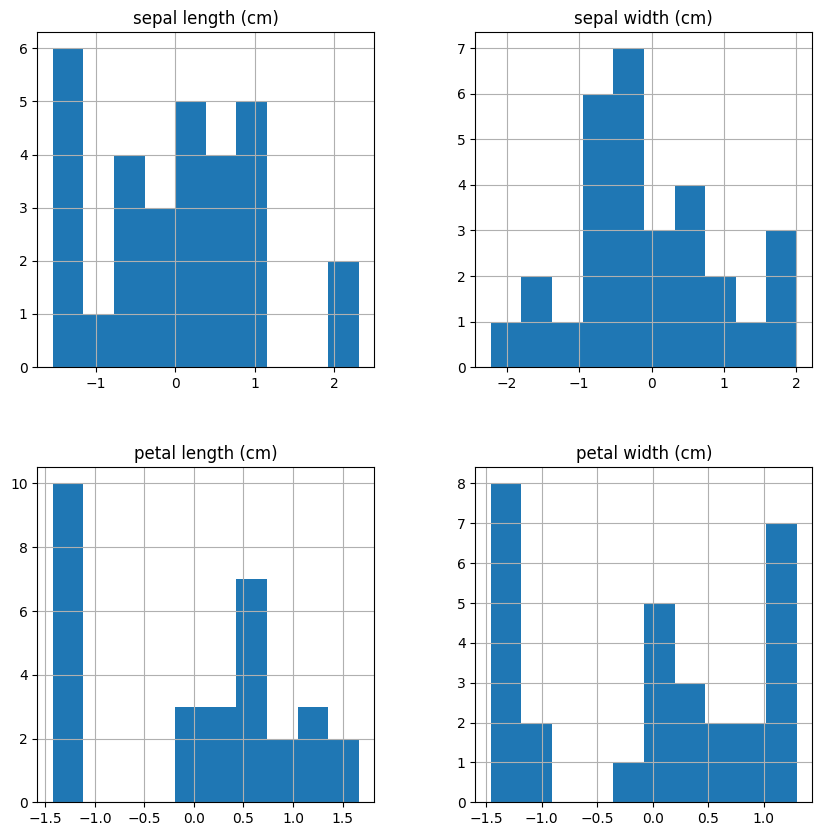

In [11]:
scaler.fit(df_test.drop('species', axis=1))

scaled_data = scaler.transform(df_test.drop('species', axis=1))

scaled_df_test = pd.DataFrame(
    scaled_data,
    columns=df.columns[:-1]   # all columns except 'species'
)

scaled_df_test.hist(figsize=(10,10))
plt.show()

In [12]:
from sklearn.linear_model import LogisticRegression

X_train = scaled_df_train
y_train = df_train['species']
X_test = scaled_df_test
y_test = df_test['species']

model = LogisticRegression()
model.fit(X_train,y_train)

LogisticRegression()

In [13]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print(f'Accuracy Score: {accuracy:.4f}')
print(f'Precision Score: {precision:.4f}')
print(f'Recall Score: {recall:.4f}')
print(f'F1 Score: {f1:.4f}')

Accuracy Score: 0.9667
Precision Score: 0.9700
Recall Score: 0.9667
F1 Score: 0.9668


In [14]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid to search over
# For Logistic Regression, common parameters to tune include 'C' (inverse of regularization strength)
# and 'penalty' (L1 or L2 regularization).
param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear'] # 'liblinear' solver supports both l1 and l2 penalties
}

grid = GridSearchCV(
    LogisticRegression(),
    param_grid=param_grid,
    cv=10,
    scoring='accuracy' # Specify the scoring metric, e.g., 'accuracy'
)
grid.fit(X_train,y_train);

In [15]:
print("Best parameters found by GridSearchCV:", grid.best_params_)
# pd.DataFrame(grid.cv_results_)

Best parameters found by GridSearchCV: {'C': 10, 'penalty': 'l1', 'solver': 'liblinear'}


In [16]:
# Get the best model from GridSearchCV
best_model = grid.best_estimator_

# Make predictions using the best model
y_pred_tuned = best_model.predict(X_test)

# Calculate and print evaluation metrics for the tuned model
accuracy_tuned = accuracy_score(y_test, y_pred_tuned)
precision_tuned = precision_score(y_test, y_pred_tuned, average='weighted')
recall_tuned = recall_score(y_test, y_pred_tuned, average='weighted')
f1_tuned = f1_score(y_test, y_pred_tuned, average='weighted')

print(f'\n--- Tuned Model Performance ---\n')
print(f'Accuracy Score (Tuned): {accuracy_tuned:.4f}')
print(f'Precision Score (Tuned): {precision_tuned:.4f}')
print(f'Recall Score (Tuned): {recall_tuned:.4f}')
print(f'F1 Score (Tuned): {f1_tuned:.4f}')

print(f'\n--- Default Model Performance ---\n')
print(f'Accuracy Score (Default): {accuracy:.4f}')
print(f'Precision Score (Default): {precision:.4f}')
print(f'Recall Score (Default): {recall:.4f}')
print(f'F1 Score (Default): {f1:.4f}')


--- Tuned Model Performance ---

Accuracy Score (Tuned): 0.9667
Precision Score (Tuned): 0.9700
Recall Score (Tuned): 0.9667
F1 Score (Tuned): 0.9668

--- Default Model Performance ---

Accuracy Score (Default): 0.9667
Precision Score (Default): 0.9700
Recall Score (Default): 0.9667
F1 Score (Default): 0.9668


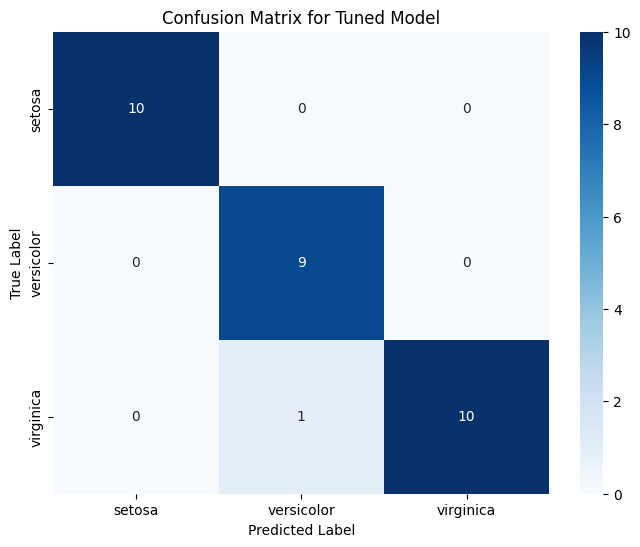

In [17]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate the confusion matrix for the tuned model
cm_tuned = confusion_matrix(y_test, y_pred_tuned)

# Get unique class names from y_test
class_names = y_test.unique()
class_names.sort() # Ensure consistent order

plt.figure(figsize=(8, 6))
sns.heatmap(cm_tuned, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix for Tuned Model')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [18]:
import pandas as pd

new_x = [-0.577740 ,1.216154, 	-1.426975 ,	-1.333701]

# Convert new_x to a DataFrame with the same column names as X_train
new_x_df = pd.DataFrame([new_x], columns=X_train.columns)

best_model.predict(new_x_df)

array([np.str_('setosa')], dtype=object)

In [19]:
import joblib

joblib.dump(best_model, 'iris_model.pkl')

['iris_model.pkl']

In [20]:
from ipywidgets import FloatText, Button, VBox, Output, HBox, Label
from IPython.display import display
import joblib

# import model
model = joblib.load('/content/iris_model.pkl')

# Create input widgets for each feature
feature_names = X_train.columns
input_widgets = []
for feature in feature_names:
    input_widgets.append(FloatText(description=feature, value=0.0))

# Create a predict button
predict_button = Button(description="Predict Species")

# Create an output widget to display results
output_area = Output()

def on_predict_button_clicked(b):
    with output_area:
        output_area.clear_output()

        # Get values from input widgets
        new_data_raw = [widget.value for widget in input_widgets]

        # Convert to DataFrame with correct column names
        new_data_df = pd.DataFrame([new_data_raw], columns=feature_names)

        # Scale the input data using the fitted scaler
        scaled_new_data = scaler.transform(new_data_df)
        scaled_new_data_df = pd.DataFrame(scaled_new_data, columns=feature_names)

        # Make prediction using the best model
        prediction = model.predict(scaled_new_data_df)

        # Display results
        print("--- User Input ---")
        display(new_data_df)
        print("\n--- Scaled Data ---")
        display(scaled_new_data_df)
        print(f"\n--- Predicted Species: {prediction[0]} ---")

# Attach the event handler to the button
predict_button.on_click(on_predict_button_clicked)

# Arrange widgets
input_vbox = VBox([Label("Enter Feature Values:")] + input_widgets)
ui = VBox([input_vbox, predict_button, output_area])

display(ui)

In [21]:
df.head()


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
